# Introduction to braching processes
Branching processes are used to model population growth by reproduction. At the start, there is just 1 individual, who produces a random number of offspring according to some pre-determined distribution. Each of these offsprings reproduce according to the same distributions. Here we will simulate two branching processes and empirically verify their results related to these processes.

First, we look at the model and certain properties of it. 

Consider $X_0,X_1,...$, where $X_n$ is the number of individuals in the $n$th generation. We assume the following:
1. $X_0$ = 1
2. Each individual lives for a unit time and produces $k$ offsprings with probability $p_k$.
3. Suppose all offsprings behave independently. Then:
   $$X_{n+1} = Y_1^n + \cdots + Y_{X_n}^n$$
   Where $Y_i^n$ are iid random variables, which are the same as $X_1$. (Note that the superscript denotes the generation)

Some facts about these processes:
If $\mathbb{E}[X_1] = \mu$ and $\text{var}(X_1) = \sigma^2$, then:
   $$\mathbb{E}[X_n] = \mu^n$$
   $$\text{var}(X_n) = \sigma^2\mu^{n-1}(1+\mu+\mu^2+\cdots+\mu^{n-1})$$

Proof of the above statements:
$$\mathbb{E}[X_n] = \mathbb{E}[\mathbb{E}[X_n | X_{n-1}]]$$
Here, $\mathbb{E}[X_n | X_{n-1} = m] = \mathbb{E}[Y_1^n + \cdots Y_m^n] = \mathbb{E}[Y_m^n] + \cdots + \mathbb{E}[Y_m^n] = \mu + \cdots + \mu = m\mu$, and thus, $\mathbb{E}[X_n | X_{n-1}] = \mu X_{n-1}$
$$\mathbb{E}[X_n] = \mathbb{E}[\mu X_{n-1}] = \mu \mathbb{E}[X_{n-1}]$$
And by induction, the result follows for $\mathbb{E}[X_n] = \mu^n$

For the variance result, first consider the identity $\mathbb{E}[X_n^2] = \text{var}(X_n) + (\mathbb{E}[X_n])^2$

$$\mathbb{E}[X_n^2] = \mathbb{E}[\mathbb{E}[X_n^2 | X_{n-1}]]$$
$$= \mathbb{E}[\text{var}(X_n) + (\mathbb{E}[X_n])^2 | X_{n-1}]$$
$$ = \mathbb{E}[X_{n-1}\text{var}(X_1) + (\mu X_{n-1})^2]$$
$$ = \sigma^2\mu^{n-1} + \mu^2\mathbb{E}[X_{n-1}^2] $$

And so, 

$$ \text{var}[X_n] = \mathbb{E}[X_n^2] - (\mathbb{E}[X_n])^2$$
$$ = \sigma^2\mu^{n-1} + \mu^2\mathbb{E}[X_{n-1}^2] - \mu^2(\mathbb{E}[X_{n-1}]^2)$$
$$ = \mu^2(\mathbb{E}[X_{n-1}^2] - \mathbb{E}[X_{n-1}]^2) + \sigma^2\mu^{n-1} $$
$$ = \mu^2(\text{var}(X_{n-1})) + \sigma^2\mu^{n-1} $$
$$ = \mu^4(\text{var}(X_{n-2})) + \sigma^2(\mu^{n-1} + \mu^n) $$
$$ \vdots $$
$$ = \sigma^2\mu^{n-1}(1+\mu+\cdots+\mu^{n-1})$$
 \begin{cases}
 \sigma^2\mu^{n-1}\frac{\mu^n - 1}{\mu - 1} & \text{ if } \mu \neq 1 \\
 n\sigma^2 & \text{ if } \mu = 1
\end{cases}

In [1]:
import numpy as np

In [2]:
rng = np.random.default_rng(seed=42)

# Uniform distribution

Suppose that $X_1 \sim U\{0,n\}$, then 
$\mathbb{P}(X_1 = k) = \begin{cases}
    \frac{1}{n+1} & \text{ if } k = 0,1,\cdots, n \\
    0 & \text{ otherwise}
\end{cases}$

$\mathbb{E}[X_1] = \frac{n}{2}$, and $\text{var}(X_1) = \frac{n(n+2)}{12}$

In [3]:
def uniform_bp(generations, potential):
    pop = np.array([1])
    for _ in range(generations):
        if pop[-1] == 0:
            pop = np.append(pop, 0)
            continue
        k = pop[-1]
        new = rng.integers(0,potential + 1,k)
        pop = np.append(pop, np.sum(new))
    return pop

In [4]:
# gen = int(input("Number of generations: "))
# pot = int(input("Maximum potential offsprings per generation: "))
gen = 5
pot = 5

mu = pot / 2
var = (pot * (pot + 2)) / 12

In [5]:
traj = uniform_bp(gen, pot)
print(f"Population Trajectory: {traj}")
print(f"Theoretical Mean: {mu ** gen}")
print(f"Error = {abs(traj[-1] - mu ** gen)}")
if mu == 1:
    var_n = gen * var
else:
    var_n = var * (mu ** (gen-1)) * (mu ** gen - 1) / (mu - 1)
print(f"Theoretical Variance: {var_n}")

Population Trajectory: [1 0 0 0 0 0]
Theoretical Mean: 97.65625
Error = 97.65625
Theoretical Variance: 7341.512044270832


### Simulating the process to get a large sample

In [6]:
def sims(num_sims, gen, pot):
    final = []
    for _ in range(num_sims):
        trajectory = uniform_bp(gen, pot) 
        final_pop = trajectory[-1] 
        final.append(final_pop)
    return np.array(final)

# sim_size = int(input("Number of simulations"))
# sim_gen = int(input("Number of generations for simulation: "))
# sim_pot = int(input("Maximum potential offsprings per individual for simultation: "))

sim_size = 1000
sim_gen = 10
sim_pot = 4

sim_results = sims(sim_size, sim_gen, sim_pot)
print(f"Empirical Mean: {np.mean(sim_results)}")
sim_mu = sim_pot / 2
print(f"Theoretical Mean: {sim_mu ** sim_gen}")

Empirical Mean: 994.579
Theoretical Mean: 1024.0


# Extinction
Another interesting property about Branching Processes is to find the probability that a branch goes extinct. 

Let $A_n$ be the event $\{X_n = 0\}$, i.e., extinction has occured by the $n$th generation. Let $q$ be the probability that extinction eventually happens.

Let $A = \bigcup_{n=1}^\infty A_n = [\text{extinction eventually occurs}]$

Since $A_1 \subseteq A_2 \subseteq A_3 \subseteq \cdots$, we infer that $q = \mathbb{P}(A) = \lim_{n\to\infty} P(A_n) = \lim_{n\to\infty} P(X_n = 0)$.

Now, let $F$ be the probability generating function of $X_1$, i.e., $$F(x) = \sum_{n=0}^\infty \mathbb{P}(X_1 = n)x^n$$
And thus, $\mathbb{P}(X_1 = 0) = F(0)$

Let the pgf of $X_i$ be $F_i(z)$, then it can be proven that $F_{n+1}(z) = F_n(F(z)) = F(F(F(\cdots(z)\cdots)))$.

So,  $$F(q) = F(\lim_{n\to\infty} F_n(0)) = \lim_{n\to\infty} F(F_n(0)) = \lim_{n\to\infty} F_{n+1} (0) = q$$
$$\implies F(q) = q$$
This means $q$ is a fixed point of $F$.

$\textbf{Theorem.}$ The probability of extinction $q$ is the smallest root to the equation $q = F(q)$. And if $\mathbb{E}[X_1] \leq 1$, then $q = 1$ (extinction is almost surely guaranteed); if $\mathbb{E}[X_1] > 1$, then $q < 1$

## Returning to uniform distribution

To find the probability of extinction, we have to solve $F(s) = s$, and for the discrete uniform distribution,
$$ F(s) = \frac{1}{n + 1} \sum_{k=0}^n s^k$$
Thus, we need to solve $$\left(\frac{1}{n + 1} \sum_{k=0}^n s^k\right) - s = 0$$

In [7]:
coeff = np.ones(pot + 1)
coeff = coeff * (1 / (pot + 1))
coeff[-2] = coeff[-2] - 1

roots = np.roots(coeff)

roots = roots[np.isreal(roots)].real # Of course, we will only consider real roots
roots = roots[roots >= 0] # Real, positive roots only
q_t = np.min(roots)
print(f"The probability of extinction, q = {q_t:.4f}")

The probability of extinction, q = 0.2113


Now, lets simulate and check if this is true or not.

`sim_results` saves the simulation results. So all we need to do is count the ratio of zeroes in the array to the number of total simulations.

In [8]:
num_zeros = np.count_nonzero(sim_results == 0)

q = num_zeros / sim_size

print(f"q = {q}")

print(f"Difference between theoretical q and empirical q: {abs(q_t - q):.4f}")

q = 0.271
Difference between theoretical q and empirical q: 0.0597


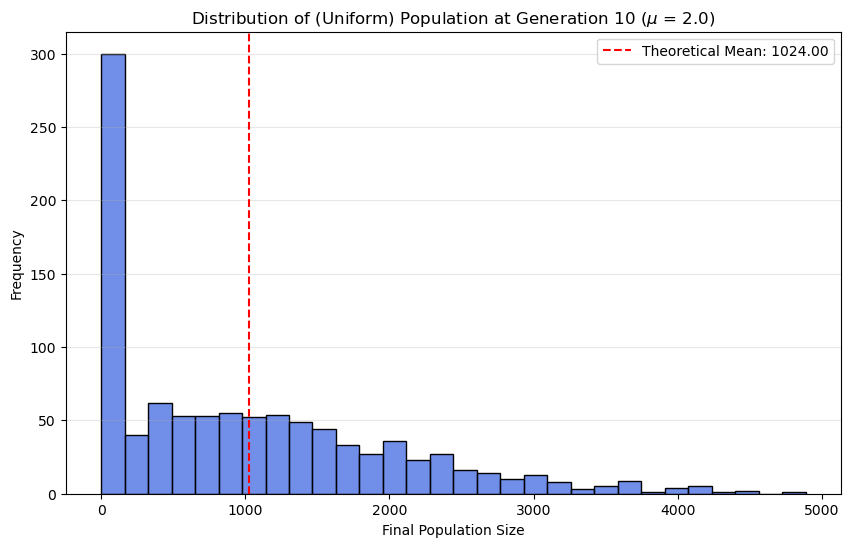

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

data = sim_results

plt.figure(figsize=(10, 6))

# Plotting the histogram

sns.histplot(data, bins=30, color='royalblue')

plt.axvline(sim_mu ** sim_gen, color='red', linestyle='--', label=f'Theoretical Mean: {sim_mu ** sim_gen:.2f}') # Mean line

plt.title(f'Distribution of (Uniform) Population at Generation {sim_gen} ($\mu$ = {sim_mu})')
plt.xlabel('Final Population Size')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Poisson Distribution

$X_1 \sim \text{Possion}(\lambda)$, then 
$\mathbb{P}(X_1 = x) = \begin{cases} 
\dfrac{e^{-\lambda}\lambda^x}{x!} & \text{ if } x = 0,1,2,\ldots \\
0 & \text{ otherwise } 
\end{cases}$

$\mathbb{E}[X_1] = \lambda = \sigma^2$
Thus, $\mathbb{E}[X_n] = (\lambda)^n$, $\text{var}(X_n) = \frac{\lambda^n(\lambda^n-1)}{\lambda-1}$, if $\lambda \neq 0$, and $\text{var}(X_n) = n$, if $\lambda = 1$

In [10]:
def poisson_bp(generations, mean):
    pop = np.array([1])
    for _ in range(generations):
        if pop[-1] == 0:
            pop = np.append(pop, 0)
            continue
        k = pop[-1]
        new = rng.poisson(lam = mean, size = k)
        pop = np.append(pop, np.sum(new))
    return pop

In [11]:
# gen_2 = int(input("Number of generations: "))
# mu_2 = float(input("Mean of the poisson distribution: "))

gen_2 = 4
mu_2 = 2

In [12]:
traj_2 = poisson_bp(gen_2, mu_2)
print(f"Population Trajectory: {traj_2}")
print(f"Theoretical Mean: {mu_2 ** gen_2}")
print(f"Error = {abs(traj_2[-1] - mu_2 ** gen_2)}")
if mu_2 == 1:
    var_n_2 = gen_2
else:
    var_n_2 = ((mu_2 ** (2*gen_2)) - (mu_2 ** gen_2)) / (mu_2 - 1)
print(f"Theoretical Variance: {var_n_2}")

Population Trajectory: [ 1  5  7 23 47]
Theoretical Mean: 16
Error = 31
Theoretical Variance: 240.0


In [13]:
def sims_2(num_sims, generation, mean):
    final = []
    for _ in range(num_sims):
        trajectory = poisson_bp(generation, mean) 
        final_pop = trajectory[-1] 
        final.append(final_pop)
    return np.array(final)

# sim_size_2 = int(input("Number of simulations"))
# sim_gen_2 = int(input("Number of generations for simulation: "))
# sim_lam = float(input("Mean for the simulated poisson distribution: "))

sim_size_2 = 1000
sim_gen_2 = 10
sim_lam = 3

sim_results_2 = sims_2(sim_size_2, sim_gen_2, sim_lam)
print(f"Empirical Mean: {np.mean(sim_results_2)}")
print(f"Theoretical Mean: {sim_lam ** sim_gen_2}")

# Check the behavior for lambda <= 1 and lambda > 1. Do note that if lambda = 1, exctinction occurs VERY slowly, compared to lambda < 1.

Empirical Mean: 59040.799
Theoretical Mean: 59049


# Extinction in Poisson

The smallest root for $F(s) = s$ in this case is a hard thing to solve since it is a transcendental equation. 
First, lets see what $F$ is: 
$$F(x) = \sum_{n=0}^\infty \mathbb{P}(X_1=n)x^n = \sum_{n=0}^\infty \frac{\lambda^n e^{-\lambda}x^n}{n!} = e^{-\lambda} \sum_{n=0}^\infty \frac{(x\lambda)^n}{n!} = e^{-\lambda}e^{x\lambda} = e^{\lambda(x-1)}$$
So we need to solve $e^{\lambda(x-1)} - x = 0$

First, we notice that $x=1$ is always a root of this equation.

Now, if $\mathbb{E}[X_1] = \lambda$ is less than or equal to 1, then $q$ is trivially 1 (from the theorem mentioned above). 

So we only need to consider the cases where $\lambda > 1$, for this case, we will ignore the root 1 of the equation and focus on the smaller root. For this, we use the SciPy library. 

`fsolve` from scipy.optimize uses the Powell's Hybrid algorithm, the conditions of which hold, since the Jacobian (simply the derivative in this case) stays non singular (non zero, here) on each neighbourhood of the true extinction probability $q_k < 1$.

To guarantee this, first, let $g(x) = e^{\lambda(x-1)} - x$. Hence, $g'(x) = \lambda e^{\lambda(x-1)} - 1$ which is zero iff $x=1$, but we won't guess $x=1$ (since it is already a root, as observed above), so we are safe from this condition.

So, we may intuitively guess $q_0=0$, a grim assumption that the population dies off.

In [14]:
from scipy.optimize import fsolve

f = lambda x: (np.e ** ((sim_lam) * (x-1))) - x

root = fsolve(f, 0)
q_t_2 = root[0]
print(f"Theoretical q: {q_t_2}")

Theoretical q: 0.05952020929264036


In [15]:
num_zeros_2 = np.count_nonzero(sim_results_2 == 0)

q = num_zeros_2 / sim_size_2

print(f"q = {q}")

print(f"Difference between theoretical q and empirical q: {abs(q_t_2 - q):.4f}")

q = 0.057
Difference between theoretical q and empirical q: 0.0025


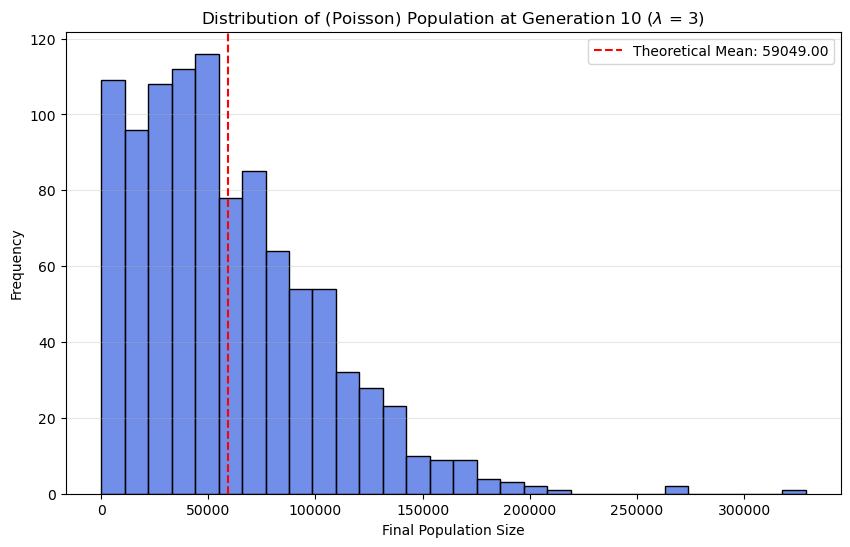

In [16]:
data_2 = sim_results_2

plt.figure(figsize=(10, 6))

# Plotting the histogram

sns.histplot(data_2, bins=30, color='royalblue')

plt.axvline(sim_lam ** sim_gen_2, color='red', linestyle='--', label=f'Theoretical Mean: {sim_lam ** sim_gen_2:.2f}') # Mean line

plt.title(f'Distribution of (Poisson) Population at Generation {sim_gen_2} ($\lambda$ = {sim_lam})')
plt.xlabel('Final Population Size')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# $q$ v/s $\lambda$

Finally, we check how $q$ behaves as a function of lambda.

In [17]:
l = np.linspace(0,3,500)
q_l = []
for w in l:
    if w <= 1:
        q_l = np.append(q_l, 1)
        continue
    else:
        f = lambda x: (np.e ** ((w) * (x-1))) - x    
        root = fsolve(f,0)
        q_l = np.append(q_l, root)

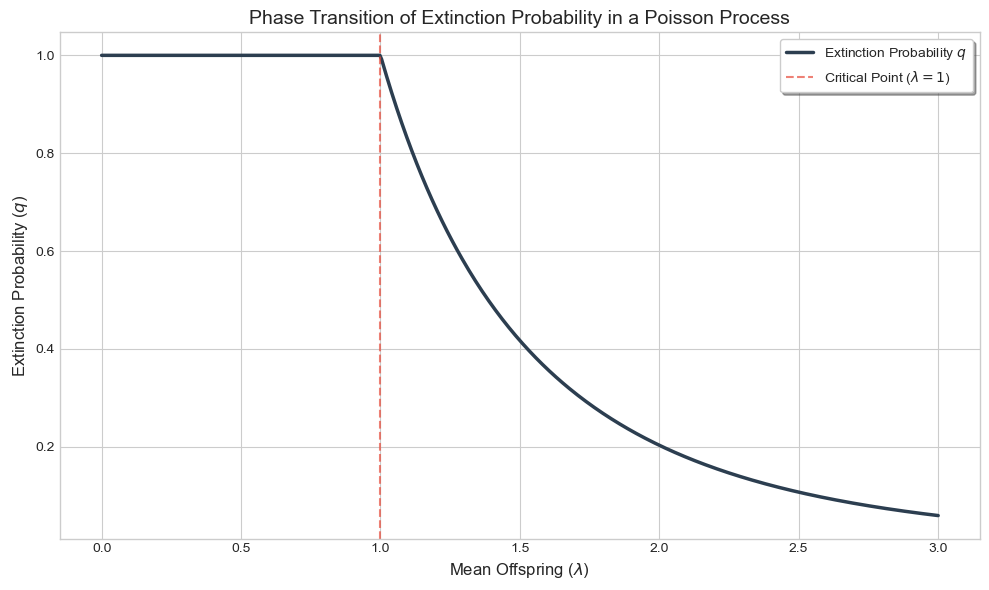

In [18]:
plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(10, 6))

plt.xlabel(r"Mean Offspring ($\lambda$)", fontsize=12)
plt.ylabel(r"Extinction Probability ($q$)", fontsize=12)
plt.title(r"Phase Transition of Extinction Probability in a Poisson Process", fontsize=14)
plt.plot(l,q_l, color='#2c3e50', linewidth=2.5, label='Extinction Probability $q$')
plt.axvline(1, color='#e74c3c', linestyle='--', alpha=0.7, label='Critical Point ($\lambda=1$)')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# Conclusion

In this project, we successfully modeled the Galton-Watson Branching Process using discrete Uniform and Poisson offspring distributions. By the use of simulations, several key properties were verified:
1. The simulations clearly demonstrated the critical threshold at $\mathbb{E}[X]=1$. In subcritical and critical cases, the population hit the absorbing state of zero almost surely, while the supercritical case allowed for a non-zero probability of ultimate survival.
2. By solving the transcendental equation $F(s)=s$ using numerical methods (`Numpy`'s roots and `SciPy`’s fsolve), we determined the theoretical extinction probability $q$. These values closely matched the empirical ratio of extinctions found in my Monte Carlo simulations.

This study reinforces the power of Probability Generating Functions (PGFs) in predicting long-term behavior in stochastic systems.